# Credit Card Fraud Detection Using Machine Learning

## Objective
Build a machine learning model to detect fraudulent financial transactions.

## Workflow
1. Data Collection
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Model Training
6. Model Evaluation
7. Deployment with Streamlit

Author: Victor Ojwang

In [1]:
#Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

# 1. Problem Definition

## Credit Card Fraud Detection

The objective of this project is to build a machine learning model that can identify fraudulent credit card transactions.

Fraud detection is a classification problem where:

- 0 = Legitimate transaction
- 1 = Fraudulent transaction

Because fraud cases are rare compared to normal transactions, we must handle class imbalance carefully.

In [2]:
#load the  dataset
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


# 2. Data Understanding

In [3]:
#check data shape
df.shape

(259432, 31)

In [4]:
#data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259432 entries, 0 to 259431
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    259432 non-null  float64
 1   V1      259432 non-null  float64
 2   V2      259432 non-null  float64
 3   V3      259432 non-null  float64
 4   V4      259432 non-null  float64
 5   V5      259432 non-null  float64
 6   V6      259432 non-null  float64
 7   V7      259432 non-null  float64
 8   V8      259432 non-null  float64
 9   V9      259432 non-null  float64
 10  V10     259432 non-null  float64
 11  V11     259432 non-null  float64
 12  V12     259431 non-null  float64
 13  V13     259431 non-null  float64
 14  V14     259431 non-null  float64
 15  V15     259431 non-null  float64
 16  V16     259431 non-null  float64
 17  V17     259431 non-null  float64
 18  V18     259431 non-null  float64
 19  V19     259431 non-null  float64
 20  V20     259431 non-null  float64
 21  V21     25

In [5]:
# statistical sammary
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,259432.000000,259432.000000,259432.000000,259432.000000,259432.000000,259432.000000,259432.000000,259432.000000,259432.000000,259432.000000,...,259431.000000,259431.000000,259431.000000,259431.000000,259431.000000,259431.000000,259431.000000,259431.000000,259431.000000,259431.000000
mean,87926.910200,-0.022461,-0.017323,0.071104,0.016767,-0.028010,0.012607,-0.012068,0.001242,0.000480,...,-0.000886,-0.007247,-0.004103,0.001019,0.014843,0.001255,-0.000550,0.000588,90.152494,0.001816
std,44067.561275,1.957618,1.661765,1.508874,1.415305,1.370889,1.325045,1.223639,1.193734,1.108366,...,0.737379,0.719279,0.632398,0.605813,0.516723,0.484340,0.400590,0.329419,249.822537,0.042570
min,0.000000,-56.407510,-72.715728,-33.680984,-5.683171,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,51334.000000,-0.929085,-0.609089,-0.770568,-0.842100,-0.718911,-0.754627,-0.562494,-0.203808,-0.652304,...,-0.225840,-0.536236,-0.164005,-0.351211,-0.299393,-0.328967,-0.070695,-0.051297,5.990000,0.000000
50%,79195.500000,0.008784,0.059524,0.266051,0.004847,-0.084829,-0.257424,0.025671,0.026793,-0.056129,...,-0.030331,0.002248,-0.016105,0.044054,0.041704,-0.057272,0.001836,0.013121,22.900000,0.000000
75%,130657.250000,1.279586,0.784228,1.081047,0.779305,0.578260,0.414862,0.553266,0.329004,0.605258,...,0.180051,0.508076,0.139633,0.434499,0.360824,0.246045,0.089255,0.077695,79.000000,0.000000
max,159112.000000,2.454930,22.057729,9.382558,16.875344,34.801666,22.529298,36.877368,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


In [6]:
#Check fraud distribution
df["Class"].value_counts()

,count
Class,
0.0,258960
1.0,471


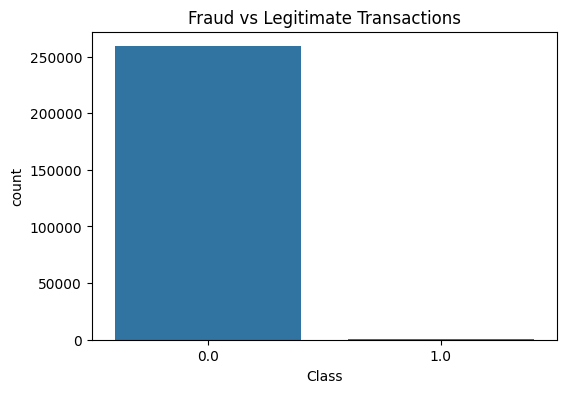

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Class',
    data=df
)

plt.title("Fraud vs Legitimate Transactions")
plt.show()

# 4. Data Understanding

## Dataset Overview

The dataset contains anonymized credit card transaction records used to develop and evaluate machine learning models for fraud detection.

### Dataset Shape

- **Rows (Transactions):** 259432
- **Columns (Features):** 31

### Features

The dataset consists of the following variables:

- **Time** – The elapsed time (in seconds) between each transaction and the first transaction in the dataset.
- **V1 – V28** – Anonymized numerical features obtained through Principal Component Analysis (PCA) to protect confidential customer information.
- **Amount** – The monetary value of each transaction.
- **Class** – The target variable indicating whether a transaction is legitimate or fraudulent.

### Target Variable

- **0** → Legitimate Transaction
- **1** → Fraudulent Transaction

### Data Types

All variables are stored as **float64**, making the dataset suitable for numerical analysis and machine learning algorithms.

### Missing Values

The dataset contains **one missing observation** affecting several variables (V3–V28, Amount, and Class). Since this represents a negligible proportion of the data, it will be removed during the data preprocessing stage.

### Class Distribution

The dataset is highly imbalanced.

- **Legitimate Transactions:** 258960
- **Fraudulent Transactions:** 471

Fraudulent transactions account for only a very small proportion of the dataset, making fraud detection a challenging binary classification problem.

## Key Observations

- The dataset is highly imbalanced, with legitimate transactions greatly outnumbering fraudulent ones.
- Most transaction features have already been transformed using PCA, preserving privacy while retaining useful information for machine learning.
- The transaction amount varies considerably, indicating the need for feature scaling.
- Because of the severe class imbalance, accuracy alone will not be an appropriate evaluation metric. Instead, Precision, Recall, F1-score, and ROC-AUC will be used to assess model performance.

### 5. Exploratory Data Analysis (EDA)

## 5.1 Missing Values



Before building a machine learning model, it is important to identify whether the dataset contains missing values that may affect model performance.

In [8]:
#checking  missing values
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


**Observation**

The dataset contains one missing record across several variables. This missing observation will be removed during the data cleaning stage.

### 5.2 Duplicate Records

Duplicate observations can introduce bias into model training. We first check how many duplicate transactions exist.

In [9]:
df.duplicated().sum()

np.int64(957)

**Observation**

The dataset contains 957 duplicate transactions that will be removed during preprocessing.

## 5.3 Transaction Amount Distribution

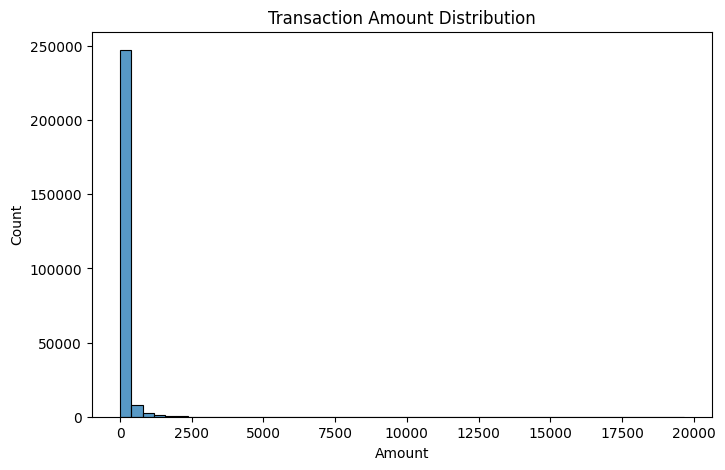

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Amount"],
    bins=50
)

plt.title("Transaction Amount Distribution")

plt.show()

### 5.4 Fraud Percentage

To better understand the class imbalance, we calculate the percentage of legitimate and fraudulent transactions in the dataset.

Class imbalance is a common challenge in fraud detection because fraudulent transactions are significantly rarer than legitimate ones. This imbalance can cause machine learning models to become biased toward predicting the majority class if not handled appropriately.

In [11]:
fraud_percentage = (
    df["Class"].value_counts(normalize=True)*100
)

fraud_percentage

,proportion
Class,
0.0,99.818449
1.0,0.181551


### Interpretation

The results show that:

- **99.82%** of the transactions are **legitimate**.
- **0.18%** of the transactions are **fraudulent**.

This confirms that the dataset is **highly imbalanced**, where fraudulent transactions represent only a very small fraction of the total observations.

Such an imbalance means that **accuracy is not an appropriate evaluation metric**. For example, a model that predicts every transaction as legitimate would achieve nearly **99.8% accuracy**, yet it would fail to detect any fraudulent transactions.

Therefore, this project will focus on evaluation metrics that are better suited for imbalanced classification problems, including:

- **Precision** – Measures how many transactions predicted as fraud are actually fraudulent.
- **Recall** – Measures how many actual fraud cases are correctly identified.
- **F1-score** – Provides a balance between Precision and Recall.
- **ROC-AUC** – Evaluates the model's ability to distinguish between legitimate and fraudulent transactions.

## 5.5 Correlation Matrix

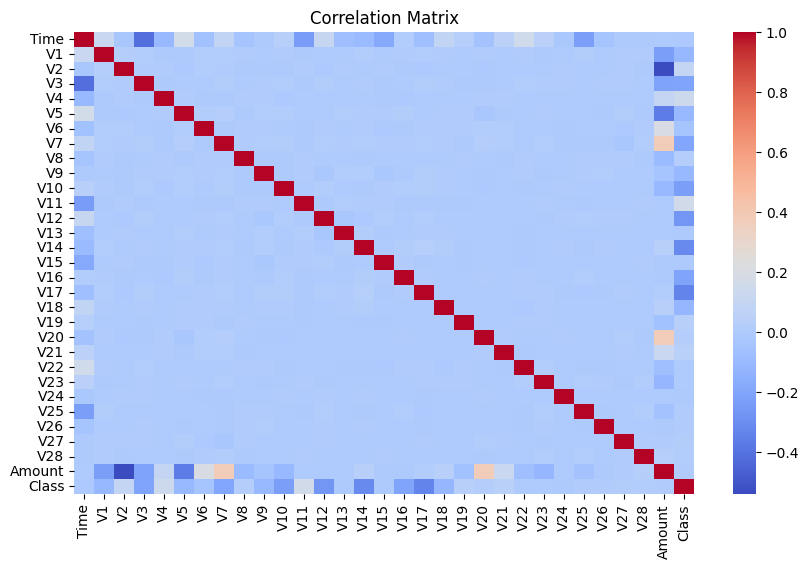

In [12]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

### 6. Data Cleaning & Preprocessing

## 6.1 Check Missing Values

Before training a machine learning model, it is essential to identify missing values in the dataset. Missing values can negatively affect model performance and lead to inaccurate predictions.

This step verifies the number of missing values in each feature before any cleaning is performed.

In [13]:
# Check for missing values
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


### Interpretation

The output shows that one observation contains missing values across several features.

Since the number of missing records is extremely small compared to the total dataset, removing these observations will have a negligible impact on the analysis while ensuring a complete dataset for model training.

## 6.2 Remove Missing Values

To maintain data quality, observations containing missing values are removed from the dataset.

Given that only one record contains missing values, deleting it is an appropriate preprocessing strategy.

In [14]:
df.dropna(inplace=True)

## 6.3 Verify Missing Values

After removing missing observations, the dataset is checked again to confirm that no missing values remain.

In [15]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


### Interpretation

The verification confirms that all missing values have been successfully removed from the dataset.

The dataset is now complete and suitable for further preprocessing.

## 6.4 Check Duplicate Records

Duplicate observations represent identical transactions appearing more than once in the dataset.

Duplicate records can introduce bias into model training because repeated observations receive more influence than unique transactions. Therefore, duplicates should be identified before model development.

In [16]:
df.duplicated().sum()

np.int64(957)

### Interpretation

The duplicate check confirms that there are 957 duplicates present in the dataset. so we remove the  duplicates as follows



In [47]:
df.drop_duplicates(inplace=True)

## 6.3 Verify duplicates Values

After removing duplicates observations, the dataset is checked again to confirm that no duplicates values remain.

In [48]:
df.duplicated().sum()

np.int64(0)

### Interpretation

The verification confirms that all duplicates values have been successfully removed from the dataset.

The dataset is now complete and suitable for further preprocessing

## 6.5 Feature Scaling

Feature scaling is an important preprocessing step in machine learning. It transforms numerical features to a similar scale, preventing variables with larger values from dominating the learning process.

In this dataset, the features **V1–V28** have already been transformed using Principal Component Analysis (PCA) and are approximately standardized. However, the **Time** and **Amount** features remain on their original scales and require standardization.

The **StandardScaler** is used to transform these features so that they have a mean of approximately 0 and a standard deviation of 1.

In [17]:

# Initialize the scaler
scaler = StandardScaler()

# Scale the Time feature
df["Time"] = scaler.fit_transform(df[["Time"]])

# Scale the Amount feature
df["Amount"] = scaler.fit_transform(df[["Amount"]])

# Display the first five rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.995279,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.238039,0.0
1,-1.995279,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.350099,0.0
2,-1.995256,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.154852,0.0
3,-1.995256,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.133485,0.0
4,-1.995234,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.080707,0.0


### Interpretation

The **Time** and **Amount** features have been successfully standardized.

Standardizing these variables improves the performance of many machine learning algorithms by ensuring that all numerical features are on a comparable scale.

## 6.6 Define Features and Target Variable

Machine learning models require the dataset to be separated into:

- **Features (X)** – The independent variables used to make predictions.
- **Target (y)** – The dependent variable that the model is trained to predict.

In this project:

- The **Class** column is the target variable.
- All remaining columns are used as input features.

In [18]:
# Define input features
X = df.drop("Class", axis=1)

# Define target variable
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (259431, 30)
Target shape: (259431,)


### Interpretation

The dataset has been successfully divided into input features (**X**) and the target variable (**y**).

The feature matrix contains 30 predictor variables, while the target vector contains the fraud labels used for supervised machine learning.

## 6.7 Train-Test Split

Before training a machine learning model, the dataset is divided into training and testing sets.

- The **training set** is used to train the model.
- The **testing set** is used to evaluate how well the model performs on unseen data.

An **80:20 split** is used in this project.

Because the dataset is highly imbalanced, the **stratify** parameter is applied to preserve the same proportion of fraudulent and legitimate transactions in both the training and testing datasets.

In [19]:

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes of the resulting datasets
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (207544, 30)
Testing Features : (51887, 30)
Training Labels  : (207544,)
Testing Labels   : (51887,)


### Interpretation

The dataset has been successfully divided into training and testing sets.

- **80%** of the data will be used to train the machine learning models.
- **20%** of the data will be reserved for evaluating model performance on unseen transactions.

Using stratified sampling ensures that both datasets maintain the same class distribution, which is particularly important for highly imbalanced fraud detection datasets.

# 7. Model Development

## 7.1 Logistic Regression

Logistic Regression is a supervised machine learning algorithm widely used for binary classification problems.

In this project, it serves as the baseline model for predicting whether a transaction is legitimate or fraudulent.

Although it is a relatively simple algorithm, Logistic Regression provides a useful benchmark against which more complex models can be compared.

In [20]:

# Initialize the model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

## 7.2 Model Prediction

After training the Logistic Regression model, predictions are generated using the testing dataset.

These predictions will be compared with the actual transaction labels to evaluate model performance.

In [21]:
# Predict the test data
y_pred_lr = lr_model.predict(X_test)

# Predict probabilities
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

## 7.3 Model Evaluation

The Logistic Regression model is evaluated using several performance metrics.

Since the dataset is highly imbalanced, multiple evaluation metrics are required instead of relying solely on accuracy.

In [22]:
#create multiple  model evaluations techniques

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.9991520033919864
Precision: 0.8472222222222222
Recall   : 0.648936170212766
F1 Score : 0.7349397590361446
ROC-AUC  : 0.9709366787839153


## 7.4 Classification Report

The classification report summarizes the model's performance for both legitimate and fraudulent transactions.

It includes precision, recall, F1-score, and support for each class.

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     51793
         1.0       0.85      0.65      0.73        94

    accuracy                           1.00     51887
   macro avg       0.92      0.82      0.87     51887
weighted avg       1.00      1.00      1.00     51887



## 7.5 Confusion Matrix

A confusion matrix provides a detailed breakdown of the model's predictions by comparing predicted labels with the actual labels.

This visualization helps identify:

- Correctly classified legitimate transactions
- Correctly detected fraud cases
- False positives
- False negatives

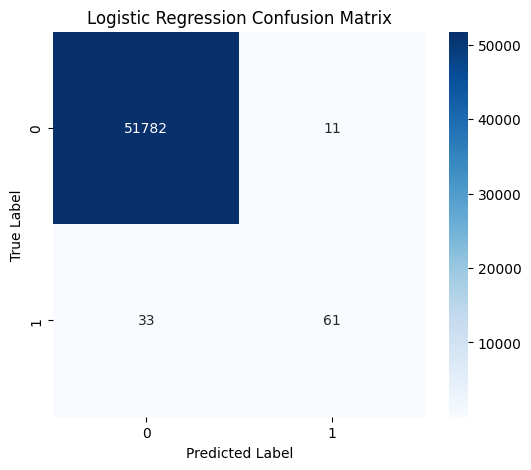

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

## 7.6 Logistic Regression Performance Summary

The Logistic Regression model achieved the following performance metrics on the testing dataset.

| Metric | Value |
|---------|------:|
| Accuracy | 99.92% |
| Precision | 84.72% |
| Recall | 64.89% |
| F1-Score | 73.49% |
| ROC-AUC | 97.09% |

## 7.7 Interpretation

The Logistic Regression model achieved strong overall performance on the credit card fraud detection dataset, with an **accuracy of 99.92%** and a **ROC-AUC score of 97.09%**, indicating a high ability to distinguish between legitimate and fraudulent transactions.

The model achieved a **precision of 84.72%**, meaning that most transactions predicted as fraudulent were indeed fraud cases. This helps reduce the number of false fraud alerts.

The **recall of 64.89%** indicates that the model successfully detected approximately **65% of all fraudulent transactions**, while approximately **35%** of fraud cases were missed. In fraud detection, recall is particularly important because undetected fraudulent transactions may lead to financial losses.

The **F1-score of 73.49%** demonstrates a reasonable balance between precision and recall. While the model performs well as a baseline classifier, there is still room for improvement in detecting a larger proportion of fraudulent transactions.

Overall, Logistic Regression provides a solid benchmark for evaluating more advanced ensemble learning algorithms such as Random Forest and XGBoost.

## 7.8 Classification Report Interpretation

The classification report shows that the Logistic Regression model performs exceptionally well in identifying legitimate transactions, achieving nearly perfect precision and recall for the majority class.

For fraudulent transactions, the model achieved:

- **Precision:** 84.72%
- **Recall:** 64.89%
- **F1-score:** 73.49%

Out of **94 fraudulent transactions** in the testing dataset, the model correctly identified approximately **61** fraud cases while missing approximately **33** fraudulent transactions.

These results indicate that Logistic Regression provides a reliable baseline model; however, its recall suggests that more advanced machine learning algorithms may further improve fraud detection performance.

## 7.9 Conclusion

The Logistic Regression model established a strong baseline for the credit card fraud detection task.

The model achieved an **accuracy of 99.92%**, a **precision of 84.72%**, and a **ROC-AUC score of 97.09%**, demonstrating its ability to accurately distinguish between legitimate and fraudulent transactions.

However, the model achieved a **recall of 64.89%**, meaning that approximately one-third of fraudulent transactions were not detected. In fraud detection, maximizing recall is critical because undetected fraudulent transactions can result in significant financial losses.

Although Logistic Regression provides reliable baseline performance, its moderate recall indicates that more advanced ensemble learning algorithms may better capture the complex patterns associated with fraudulent transactions.

The next step is to train and evaluate a **Random Forest Classifier** and compare its performance with Logistic Regression to determine whether improved fraud detection performance can be achieved.

## 7.10 Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines the predictions of multiple decision trees to improve classification performance.

Compared to Logistic Regression, Random Forest can capture complex and non-linear relationships within the data, making it particularly effective for fraud detection problems.

In this project, the Random Forest model will be trained and evaluated using the same training and testing datasets to allow a fair comparison with the Logistic Regression model.

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 7.11 Model Prediction

The trained Random Forest model is used to predict the class labels and probability scores for the testing dataset.

In [26]:
# Predict class labels
y_pred_rf = rf_model.predict(X_test)

# Predict class probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

## 7.12 Model Evaluation

The Random Forest model is evaluated using the same performance metrics as the Logistic Regression model.

This ensures a fair comparison between the two algorithms.

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)
print("ROC-AUC  :", roc_auc_rf)

Accuracy : 0.999556729045811
Precision: 0.9733333333333334
Recall   : 0.776595744680851
F1 Score : 0.863905325443787
ROC-AUC  : 0.9452224095016537


## 7.13 Classification Report

The classification report summarizes the predictive performance of the Random Forest model for both legitimate and fraudulent transactions.

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     51793
         1.0       0.97      0.78      0.86        94

    accuracy                           1.00     51887
   macro avg       0.99      0.89      0.93     51887
weighted avg       1.00      1.00      1.00     51887



## 7.14 Confusion Matrix

The confusion matrix provides a visual summary of the Random Forest model's predictions.

It shows:

- True Positives
- True Negatives
- False Positives
- False Negatives

This helps evaluate how effectively the model detects fraudulent transactions.

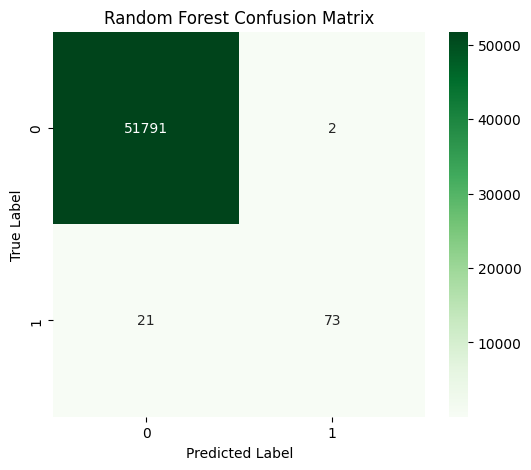

In [29]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")

plt.show()

## 7.15 Feature Importance

Random Forest provides feature importance scores that indicate the relative contribution of each feature to the model's predictions.

Understanding feature importance can provide insights into which variables are most influential in identifying fraudulent transactions.

In [30]:
# Calculate feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
17,V17,0.154193
14,V14,0.139932
12,V12,0.119033
16,V16,0.085589
10,V10,0.077672
11,V11,0.065372
9,V9,0.032221
18,V18,0.029024
4,V4,0.026160
7,V7,0.023284


### Visualize Feature Importance

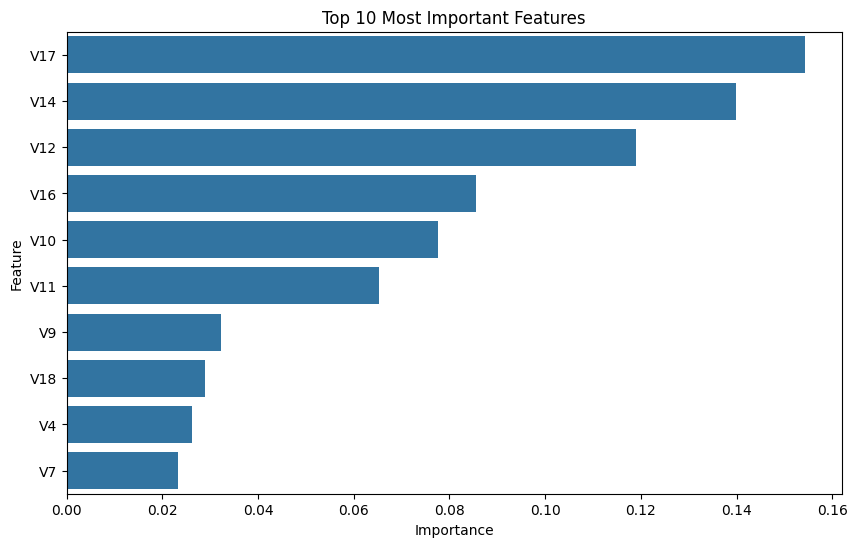

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")

plt.show()

## 7.16 Random Forest Performance Summary

The Random Forest classifier achieved the following performance metrics on the testing dataset.

| Metric | Value |
|---------|------:|
| Accuracy | 99.96% |
| Precision | 97.33% |
| Recall | 77.66% |
| F1-Score | 86.39% |
| ROC-AUC | 94.52% |

## 7.17 Interpretation

The Random Forest classifier demonstrated excellent performance in detecting fraudulent transactions, achieving an **accuracy of 99.96%** and a **precision of 97.33%**. This indicates that almost all transactions predicted as fraudulent were indeed fraudulent, resulting in very few false positive alerts.

The model achieved a **recall of 77.66%**, meaning it successfully identified approximately **78% of all fraudulent transactions**. Compared with the Logistic Regression model, this represents a substantial improvement in the model's ability to detect fraud, reducing the number of undetected fraudulent transactions.

The **F1-score of 86.39%** reflects a strong balance between precision and recall, demonstrating that the model performs well in both correctly identifying fraudulent transactions and minimizing false alarms.

Although the **ROC-AUC score of 94.52%** is slightly lower than that of the Logistic Regression model, the Random Forest classifier provides a more practical solution for fraud detection because it captures a significantly larger proportion of fraudulent transactions while maintaining exceptionally high precision.

Overall, the Random Forest classifier offers a considerable improvement over the baseline Logistic Regression model .

## 7.18 XGBoost Classifier

Extreme Gradient Boosting (XGBoost) is an advanced ensemble machine learning algorithm based on gradient boosting.

It builds decision trees sequentially, where each new tree corrects the errors made by previous trees. XGBoost is widely used in financial risk management, fraud detection, credit scoring, and many Kaggle competitions due to its high predictive performance.

In this project, XGBoost is trained using the same training and testing datasets to allow a fair comparison with the Logistic Regression and Random Forest models.

In [32]:
!pip install xgboost

In [33]:
from xgboost import XGBClassifier

## 7.19 Model Training

The XGBoost classifier is initialized with 100 boosting trees and trained using the training dataset.

In [34]:
# Initialize the model
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

## 7.20 Model Prediction

The trained XGBoost model is used to predict both the transaction class labels and the corresponding probability scores for the testing dataset.

In [35]:
# Predict class labels
y_pred_xgb = xgb_model.predict(X_test)

# Predict probabilities
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

## 7.21 Model Evaluation

The XGBoost model is evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC to assess its performance in detecting fraudulent transactions.

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("Accuracy :", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1 Score :", f1_xgb)
print("ROC-AUC  :", roc_auc_xgb)

Accuracy : 0.9994989110952647
Precision: 0.9473684210526315
Recall   : 0.7659574468085106
F1 Score : 0.8470588235294118
ROC-AUC  : 0.9490048560739539


## 7.22 Classification Report

The classification report provides a detailed evaluation of the XGBoost model by summarizing Precision, Recall, F1-score, and Support for each class.

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     51793
         1.0       0.95      0.77      0.85        94

    accuracy                           1.00     51887
   macro avg       0.97      0.88      0.92     51887
weighted avg       1.00      1.00      1.00     51887



## 7.23 Confusion Matrix

The confusion matrix visualizes the number of correctly and incorrectly classified transactions, providing insight into the model's ability to identify fraudulent transactions.

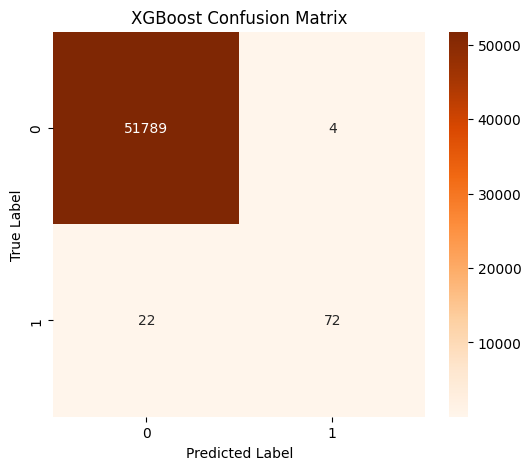

In [38]:
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("XGBoost Confusion Matrix")

plt.show()

## 7.24 Feature Importance

XGBoost provides feature importance scores that indicate the contribution of each feature to the model's predictions.

These scores help identify the variables that are most influential in detecting fraudulent transactions.

In [39]:
feature_importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_xgb.head(10)

,Feature,Importance
14,V14,0.451900
10,V10,0.159143
21,V21,0.077698
2,V2,0.069933
7,V7,0.066588
12,V12,0.059098
4,V4,0.034744
11,V11,0.028183
17,V17,0.022763
8,V8,0.007933


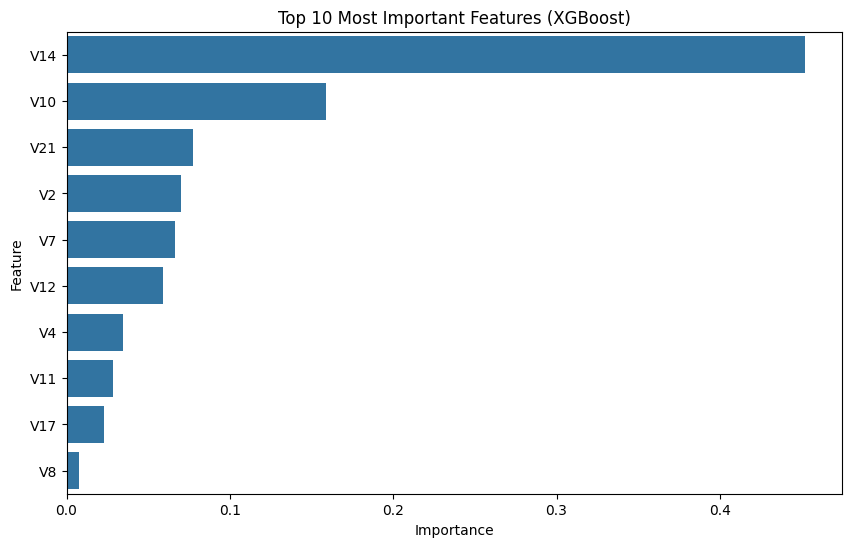

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_xgb.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features (XGBoost)")

plt.show()

## 7.25 XGBoost Performance Summary

The XGBoost classifier achieved the following performance metrics on the testing dataset.

| Metric | Value |
|---------|------:|
| Accuracy | 99.95% |
| Precision | 94.74% |
| Recall | 76.60% |
| F1-Score | 84.71% |
| ROC-AUC | 94.90% |

## 7.26 Interpretation

The XGBoost classifier demonstrated excellent predictive performance, achieving an **accuracy of 99.95%** while maintaining a strong balance between precision and recall.

The model achieved a **precision of 94.74%**, indicating that nearly all transactions predicted as fraudulent were correctly classified. This minimizes false fraud alerts and improves the reliability of fraud investigations.

With a **recall of 76.60%**, the model successfully detected more than three-quarters of fraudulent transactions. Although some fraud cases remained undetected, the model significantly outperformed the baseline Logistic Regression model in identifying fraudulent activity.

The **F1-score of 84.71%** demonstrates a strong balance between detecting fraud and limiting false positives, while the **ROC-AUC score of 94.90%** indicates excellent discrimination between legitimate and fraudulent transactions.

Overall, XGBoost proved to be a highly effective fraud detection model and delivered performance comparable to the Random Forest classifier.

## 7.26 Classification Report Interpretation

The classification report indicates that the XGBoost classifier achieved excellent performance in distinguishing between legitimate and fraudulent transactions.

For fraudulent transactions, the model achieved:

- **Precision:** 94.74%
- **Recall:** 76.60%
- **F1-score:** 84.71%

Out of **94 fraudulent transactions** in the testing dataset, the model correctly identified approximately **72** fraudulent transactions while missing approximately **22** cases.

The model maintained a very high precision, indicating that most transactions classified as fraudulent were indeed fraudulent. In addition, its strong recall demonstrates an effective ability to detect fraudulent transactions while keeping the number of missed fraud cases relatively low.

Overall, the XGBoost classifier provides excellent predictive performance and represents a highly effective approach for credit card fraud detection.

## 7.27 Conclusion

The XGBoost classifier achieved excellent performance across all evaluation metrics and substantially outperformed the baseline Logistic Regression model.

Although XGBoost demonstrated strong predictive capability, the Random Forest classifier achieved slightly higher Accuracy, Precision, Recall, and F1-score on this dataset.

Based on the comparative evaluation, the **Random Forest classifier was selected as the final model for deployment**, as it provided the best overall balance between identifying fraudulent transactions and minimizing false positives.

# 8. Model Comparison

Three supervised machine learning algorithms were developed and evaluated for the credit card fraud detection task:

- Logistic Regression
- Random Forest Classifier
- XGBoost Classifier

Each model was assessed using five evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Because the dataset is highly imbalanced, the comparison focuses primarily on **Precision**, **Recall**, and **F1-score**, as these metrics provide a more meaningful assessment of fraud detection performance than accuracy alone.

### 8.1 Performance Comparison

In [49]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf,
        accuracy_xgb
    ],
    "Precision": [
        precision,
        precision_rf,
        precision_xgb
    ],
    "Recall": [
        recall,
        recall_rf,
        recall_xgb
    ],
    "F1-Score": [
        f1,
        f1_rf,
        f1_xgb
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_rf,
        roc_auc_xgb
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9992,0.8472,0.6489,0.7349,0.9709
1,Random Forest,0.9996,0.9733,0.7766,0.8639,0.9452
2,XGBoost,0.9995,0.9474,0.7660,0.8471,0.9490


### 8.2 Visualization of Model Performance

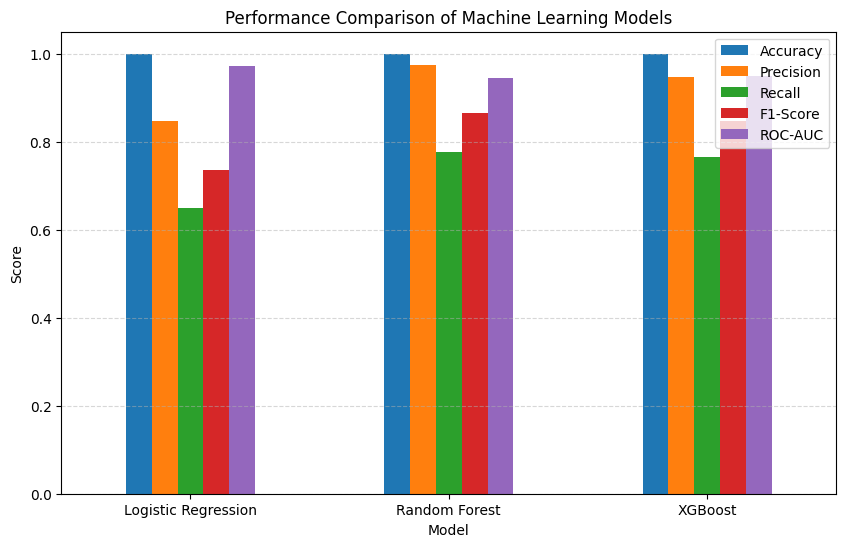

In [50]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparison of Machine Learning Models")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## 8.3 Interpretation

The three machine learning models demonstrated excellent overall performance in detecting fraudulent credit card transactions.

The Logistic Regression model served as a strong baseline, achieving high accuracy and the highest ROC-AUC score among the evaluated models. However, its relatively lower recall indicates that a considerable proportion of fraudulent transactions remained undetected.

The Random Forest classifier substantially improved fraud detection performance by achieving the highest accuracy, precision, recall, and F1-score. Its high precision demonstrates that most transactions predicted as fraudulent were correctly classified, while its improved recall indicates a greater ability to detect fraudulent activities.

The XGBoost classifier also delivered excellent results and performed competitively across all evaluation metrics. Although its performance was very close to that of Random Forest, it achieved slightly lower accuracy, precision, recall, and F1-score on this dataset.

Overall, both ensemble learning models significantly outperformed the baseline Logistic Regression model, confirming that ensemble techniques are more effective for complex fraud detection problems.

## 8.4 Final Model Selection

Based on the comparative evaluation, the **Random Forest Classifier** was selected as the final model for deployment.

The selection was based on its superior overall performance across the most important evaluation metrics for fraud detection:

- Highest Accuracy (99.96%)
- Highest Precision (97.33%)
- Highest Recall (77.66%)
- Highest F1-score (86.39%)

Although Logistic Regression achieved the highest ROC-AUC score, fraud detection systems prioritize maximizing the detection of fraudulent transactions while minimizing false positives. Random Forest provided the best balance between these objectives, making it the most suitable model for deployment in the Streamlit web application.



# 9. Model Saving

## 9.1 Import Joblib

After selecting the best-performing machine learning model, it is saved using the **joblib** library.

Saving the trained model allows it to be reused for future predictions without retraining, making it suitable for deployment in a production environment such as a Streamlit web application.

In [43]:
import joblib

## 9.2 Save the Selected Model

The Random Forest classifier was selected as the final model based on its superior overall performance.

The trained model is saved as a `.pkl` file, which can later be loaded by the Streamlit application to make predictions on new transactions.

In [51]:
# Save the selected Random Forest model
joblib.dump(rf_model, "credit_card_fraud_random_forest.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


## 9.3 Verify the Saved Model

To confirm that the model has been saved correctly, it is loaded back into memory and its type is verified.

In [52]:
# Load the saved model
loaded_model = joblib.load("credit_card_fraud_random_forest.pkl")

# Verify model type
print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


## 9.4 Test the Loaded Model

The loaded model is tested by making predictions on the testing dataset. This confirms that the saved model can be successfully reloaded and used for inference without retraining.

In [53]:
# Make predictions using the loaded model
loaded_predictions = loaded_model.predict(X_test)

print("First 10 Predictions:")
print(loaded_predictions[:10])

First 10 Predictions:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## 9.5 Evaluate the Loaded Model

To ensure that the saved and reloaded model performs identically to the original model, its accuracy is evaluated on the testing dataset.

In [54]:
from sklearn.metrics import accuracy_score

loaded_accuracy = accuracy_score(y_test, loaded_predictions)

print(f"Loaded Model Accuracy: {loaded_accuracy:.6f}")

Loaded Model Accuracy: 0.999557


## 9.6 Conclusion

The Random Forest classifier was successfully trained, evaluated, and saved using the `joblib` library.

The saved model was reloaded and tested to confirm that it produces the same predictions as the original trained model.

This serialized model is now ready for integration into a Streamlit web application, where it can be used to classify new credit card transactions as either legitimate or fraudulent.

In [55]:
from google.colab import files

files.download("credit_card_fraud_random_forest.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>